In [ ]:
from google.colab import files
files.upload()

Saving BCICIV_2b_gdf.zip to BCICIV_2b_gdf.zip


In [ ]:
!unzip BCICIV_2b_gdf.zip -d /content/data

Archive:  BCICIV_2b_gdf.zip
  inflating: /content/data/B0101T.gdf  
  inflating: /content/data/B0102T.gdf  
  inflating: /content/data/B0103T.gdf  
  inflating: /content/data/B0104E.gdf  
  inflating: /content/data/B0105E.gdf  
  inflating: /content/data/B0201T.gdf  
  inflating: /content/data/B0202T.gdf  
  inflating: /content/data/B0203T.gdf  
  inflating: /content/data/B0204E.gdf  
  inflating: /content/data/B0205E.gdf  
  inflating: /content/data/B0301T.gdf  
  inflating: /content/data/B0302T.gdf  
  inflating: /content/data/B0303T.gdf  
  inflating: /content/data/B0304E.gdf  
  inflating: /content/data/B0305E.gdf  
  inflating: /content/data/B0401T.gdf  
  inflating: /content/data/B0402T.gdf  
  inflating: /content/data/B0403T.gdf  
  inflating: /content/data/B0404E.gdf  
  inflating: /content/data/B0405E.gdf  
  inflating: /content/data/B0501T.gdf  
  inflating: /content/data/B0502T.gdf  
  inflating: /content/data/B0503T.gdf  
  inflating: /content/data/B0504E.gdf  
  inflating:

In [ ]:
pip install mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 11.6 MB/s eta 0:00:00


In [ ]:
import mne

test_file = "/content/data/B0101T.gdf"  # use any one of your files

raw = mne.io.read_raw_gdf(test_file, preload=False, verbose=False)

events, event_dict = mne.events_from_annotations(raw)

print("Event dictionary:")
print(event_dict)

/tmp/ipykernel_159/2160207769.py:5: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(test_file, preload=False, verbose=False)


Used Annotations descriptions: [np.str_('1023'), np.str_('1077'), np.str_('1078'), np.str_('1079'), np.str_('1081'), np.str_('276'), np.str_('277'), np.str_('32766'), np.str_('768'), np.str_('769'), np.str_('770')]
Event dictionary:
{np.str_('1023'): 1, np.str_('1077'): 2, np.str_('1078'): 3, np.str_('1079'): 4, np.str_('1081'): 5, np.str_('276'): 6, np.str_('277'): 7, np.str_('32766'): 8, np.str_('768'): 9, np.str_('769'): 10, np.str_('770'): 11}


In [ ]:
import os
import glob
import numpy as np
import mne

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# ================================
# 1. DATA PATH
# ================================
DATA_PATH = "/content/data"   # 🔴 CHANGE if needed

# ================================
# 2. LOAD ONLY TRAINING FILES (T)
# ================================
gdf_files = sorted(glob.glob(os.path.join(DATA_PATH, "B0*T.gdf")))

print("Found training files:", len(gdf_files))
for f in gdf_files[:5]:
    print(os.path.basename(f))

# ================================
# 3. EVENT IDs (BCI IV 2a)
# ================================
EVENT_ID = {
    '769': 0,   # left hand
    '770': 1    # right hand
}

# ================================
# 4. FILTER BANK
# ================================
bands = [
    (4, 8),
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 30)
]

X_all = []
y_all = []

# ================================
# 5. PROCESS EACH FILE
# ================================
for file in gdf_files:

    print(f"\nProcessing {os.path.basename(file)}")

    raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)

    # ✅ IMPORTANT: apply filter properly
    raw.filter(4., 38., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    # 🔴 Check available events
    available_events = set(event_dict.keys())
    valid_keys = [k for k in EVENT_ID.keys() if k in available_events]

    if len(valid_keys) < 2:
        print("Skipping file (missing classes)")
        continue

    # ================================
    # Epoch extraction
    # ================================
    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')

    epochs = mne.Epochs(
        raw,
        events,
        event_id={k: event_dict[k] for k in valid_keys},
        tmin=0.5,
        tmax=2.5,
        picks=picks,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()
    y = epochs.events[:, -1]

    # map labels to 0/1
    label_map = {event_dict[k]: EVENT_ID[k] for k in valid_keys}
    y = np.array([label_map[val] for val in y])

    X_all.append(X)
    y_all.append(y)

# ================================
# 6. CONCATENATE DATA
# ================================
X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

print("\nFinal dataset shape:", X_all.shape)

# ================================
# 7. BUILD FBCSP FEATURES PROPERLY
# ================================
from sklearn.base import BaseEstimator, TransformerMixin

class FBCSP(BaseEstimator, TransformerMixin):
    def __init__(self, bands, n_components=4, sfreq=250):
        self.bands = bands
        self.n_components = n_components
        self.sfreq = sfreq
        self.csp_list = []

    def fit(self, X, y):
        self.csp_list = []
        self.filters_ = []

        for l_freq, h_freq in self.bands:
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=l_freq,
                h_freq=h_freq,
                verbose=False
            )

            csp = CSP(n_components=self.n_components, log=True, norm_trace=False)
            csp.fit(X_band, y)

            self.csp_list.append(csp)

        return self

    def transform(self, X):
        features = []

        for (l_freq, h_freq), csp in zip(self.bands, self.csp_list):
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=l_freq,
                h_freq=h_freq,
                verbose=False
            )

            feat = csp.transform(X_band)
            features.append(feat)

        return np.concatenate(features, axis=1)

# ================================
# 8. PIPELINE (NO LEAKAGE)
# ================================
pipeline = Pipeline([
    ('fbcsp', FBCSP(bands=bands, n_components=4, sfreq=250)),
    ('lda', LinearDiscriminantAnalysis())
])

scores = cross_val_score(pipeline, X_all, y_all, cv=5)

print("\n✅ Proper FBCSP + LDA Accuracy: %.2f%%" % (np.mean(scores)*100))

Found training files: 27
B0101T.gdf
B0102T.gdf
B0103T.gdf
B0201T.gdf
B0202T.gdf

Processing B0101T.gdf


/tmp/ipykernel_159/2401568837.py:55: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)



Processing B0102T.gdf


/tmp/ipykernel_159/2401568837.py:55: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)



Processing B0103T.gdf


...


Processing B0902T.gdf


/tmp/ipykernel_159/2401568837.py:55: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)



Processing B0903T.gdf


/tmp/ipykernel_159/2401568837.py:55: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)



Final dataset shape: (3680, 6, 501)
Computing rank from data with rank=None
    Using tolerance 1.1e-05 (2.2e-16 eps * 6 dim * 8.1e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 8.6e-06 (2.2e-16 eps * 6 dim * 6.4e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 6.8e-06 (2.2e-16 eps * 6 dim * 5.1e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 c

In [ ]:
# ============================================================
# SUBJECT-WISE FBCSP + LDA (LEFT vs RIGHT)
# ============================================================

import os
import glob
import numpy as np
import mne

from mne.decoding import CSP
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin

# ================================
# USER SETTINGS
# ================================
DATA_PATH = "/content/data"
SUBJECT = "01"   # 🔴 change subject here

EVENT_ID = {
    '769': 0,   # left
    '770': 1    # right
}

bands = [
    (8, 12),
    (12, 16),
    (16, 20),
    (20, 24),
    (24, 28),
    (28, 32)
]

SFREQ = 250
N_CSP = 6

# ================================
# FIND SUBJECT FILES (T only)
# ================================
pattern = os.path.join(DATA_PATH, f"B{SUBJECT}*T.gdf")
gdf_files = sorted(glob.glob(pattern))

print(f"Subject {SUBJECT} files:", len(gdf_files))

# ================================
# LOAD DATA
# ================================
X_all = []
y_all = []

for file in gdf_files:

    print("Loading:", os.path.basename(file))

    raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)

    # broadband filter
    raw.filter(4., 38., fir_design='firwin', verbose=False)

    events, event_dict = mne.events_from_annotations(raw, verbose=False)

    available = set(event_dict.keys())
    valid_keys = [k for k in EVENT_ID if k in available]

    if len(valid_keys) < 2:
        print("Skipping file (missing class)")
        continue

    picks = mne.pick_types(raw.info, eeg=True, exclude='bads')

    epochs = mne.Epochs(
        raw,
        events,
        event_id={k: event_dict[k] for k in valid_keys},
        tmin=0.5,
        tmax=2.5,
        picks=picks,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()
    y = epochs.events[:, -1]

    label_map = {event_dict[k]: EVENT_ID[k] for k in valid_keys}
    y = np.array([label_map[v] for v in y])

    X_all.append(X)
    y_all.append(y)

# concatenate
X_all = np.concatenate(X_all, axis=0)
y_all = np.concatenate(y_all, axis=0)

print("Final shape:", X_all.shape)

# ============================================================
# FBCSP CLASS
# ============================================================

class FBCSP(BaseEstimator, TransformerMixin):
    def __init__(self, bands, n_components=6, sfreq=250):
        self.bands = bands
        self.n_components = n_components
        self.sfreq = sfreq

    def fit(self, X, y):
        self.csp_list_ = []

        for l_freq, h_freq in self.bands:
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=l_freq,
                h_freq=h_freq,
                verbose=False
            )

            csp = CSP(
                n_components=self.n_components,
                log=True,
                norm_trace=False
            )
            csp.fit(X_band, y)
            self.csp_list_.append(csp)

        return self

    def transform(self, X):
        feats = []

        for (l_freq, h_freq), csp in zip(self.bands, self.csp_list_):
            X_band = mne.filter.filter_data(
                X,
                sfreq=self.sfreq,
                l_freq=l_freq,
                h_freq=h_freq,
                verbose=False
            )

            feats.append(csp.transform(X_band))

        return np.concatenate(feats, axis=1)

# ============================================================
# PIPELINE
# ============================================================

pipeline = Pipeline([
    ('fbcsp', FBCSP(bands=bands, n_components=N_CSP, sfreq=SFREQ)),
    ('lda', LinearDiscriminantAnalysis(
        solver='lsqr',
        shrinkage='auto'
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_all, y_all, cv=cv)

print("\n✅ Subject-wise Accuracy: %.2f%% ± %.2f%%"
      % (np.mean(scores)*100, np.std(scores)*100))

Subject 01 files: 3
Loading: B0101T.gdf


/tmp/ipykernel_159/2783185774.py:57: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)


Loading: B0102T.gdf


/tmp/ipykernel_159/2783185774.py:57: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)


Loading: B0103T.gdf


/tmp/ipykernel_159/2783185774.py:57: RuntimeWarning: Highpass cutoff frequency 100.0 is greater than lowpass cutoff frequency 0.5, setting values to 0 and Nyquist.
  raw = mne.io.read_raw_gdf(file, preload=True, verbose=False)


Final shape: (400, 6, 501)
Computing rank from data with rank=None
    Using tolerance 2.3e-06 (2.2e-16 eps * 6 dim * 1.7e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.3e-06 (2.2e-16 eps * 6 dim * 1.7e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.6e-06 (2.2e-16 eps * 6 dim * 1.9e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance 

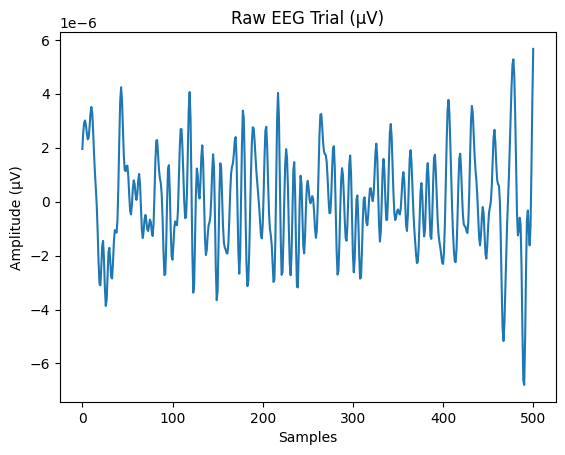

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X_all[0][0])  # first trial, first channel
plt.title("Raw EEG Trial (µV)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (µV)")
plt.show()

In [ ]:
trial = 0          # choose trial
sample = 200       # choose time instant

snapshot = X_all[trial, :, sample]

print(snapshot)

[-8.84126384e-07  1.23289061e-06  1.35096823e-06 -1.16815309e-05
 -1.07195207e-05 -8.29837677e-06]


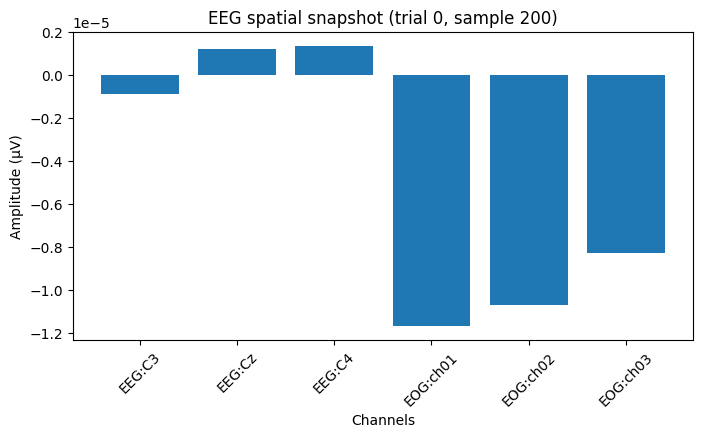

In [ ]:
import matplotlib.pyplot as plt

trial = 0
sample = 200

snapshot = X_all[trial, :, sample]
channels = epochs.ch_names  # electrode names

plt.figure(figsize=(8,4))
plt.bar(channels, snapshot)
plt.title(f"EEG spatial snapshot (trial {trial}, sample {sample})")
plt.ylabel("Amplitude (µV)")
plt.xlabel("Channels")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pipeline.fit(X_all, y_all)

Computing rank from data with rank=None
    Using tolerance 2.6e-06 (2.2e-16 eps * 6 dim * 1.9e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.6e-06 (2.2e-16 eps * 6 dim * 1.9e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.
Computing rank from data with rank=None
    Using tolerance 2.9e-06 (2.2e-16 eps * 6 dim * 2.2e+09  max singular value)
    Estimated rank (data): 6
    data: rank 6 computed from 6 data channels with 0 projectors
Reducing data rank from 6 -> 6
Estimating class=0 covariance using EMPIRICAL
Done.
Estim

Pipeline(steps=[('fbcsp',
                 FBCSP(bands=[(8, 12), (12, 16), (16, 20), (20, 24), (24, 28),
                              (28, 32)])),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

In [ ]:
trial_id = 0

X_trial = X_all[trial_id:trial_id+1]  # keep 3D shape
y_true = y_all[trial_id]

print("True label:", y_true)

True label: 0


In [ ]:
y_pred = pipeline.predict(X_trial)
print("Predicted label:", y_pred[0])

Predicted label: 1


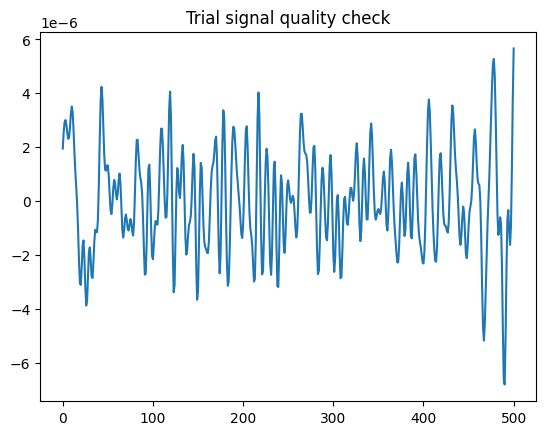

In [ ]:
import matplotlib.pyplot as plt
plt.plot(X_trial[0][0])
plt.title("Trial signal quality check")
plt.show()

In [ ]:
trial_id = 10   # 🔴 change to any index

X_trial = X_all[trial_id:trial_id+1]
y_true = y_all[trial_id]

print("True label:", y_true)

y_pred = pipeline.predict(X_trial)
print("Predicted label:", y_pred[0])

proba = pipeline.predict_proba(X_trial)
print("Probabilities:", proba)

decision = pipeline.decision_function(X_trial)
print("Decision value:", decision)

True label: 1
Predicted label: 1
Probabilities: [[0.08499704 0.91500296]]
Decision value: [2.37631084]


In [ ]:
!pip install tensorflow

In [ ]:
X_dl = X_all.copy()

# normalize (VERY IMPORTANT)
X_dl = (X_dl - X_dl.mean(axis=2, keepdims=True)) / (
        X_dl.std(axis=2, keepdims=True) + 1e-6)

# add channel dimension
X_dl = X_dl[..., np.newaxis]

print("EEGNet input shape:", X_dl.shape)

EEGNet input shape: (400, 6, 501, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_eegnet(n_channels, n_samples, n_classes=2):

    input1 = layers.Input(shape=(n_channels, n_samples, 1))

    # Temporal convolution
    x = layers.Conv2D(8, (1, 64), padding='same', use_bias=False)(input1)
    x = layers.BatchNormalization()(x)

    # Depthwise spatial convolution (like CSP)
    x = layers.DepthwiseConv2D((n_channels, 1),
                               depth_multiplier=2,
                               use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 4))(x)
    x = layers.Dropout(0.5)(x)

    # Separable convolution
    x = layers.SeparableConv2D(16, (1, 16),
                               padding='same',
                               use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('elu')(x)
    x = layers.AveragePooling2D((1, 8))(x)
    x = layers.Dropout(0.5)(x)

    x = layers.Flatten()(x)
    output = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs=input1, outputs=output)
    return model

In [ ]:
X_eegnet = X_all[..., np.newaxis]

print("EEGNet input shape:", X_eegnet.shape)

EEGNet input shape: (400, 6, 501, 1)


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, DepthwiseConv2D
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.layers import AveragePooling2D, Dropout
from tensorflow.keras.layers import SeparableConv2D, Flatten, Dense
from tensorflow.keras.constraints import max_norm

def build_eegnet(nb_classes=2, Chans=22, Samples=500):

    input1 = Input(shape=(Chans, Samples, 1))

    # Block 1
    x = Conv2D(16, (1, 64), padding='same', use_bias=False)(input1)
    x = BatchNormalization()(x)

    x = DepthwiseConv2D(
        (Chans, 1),
        use_bias=False,
        depth_multiplier=2,
        depthwise_constraint=max_norm(1.)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 4))(x)
    x = Dropout(0.5)(x)

    # Block 2
    x = SeparableConv2D(16, (1, 16), use_bias=False, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = AveragePooling2D((1, 8))(x)
    x = Dropout(0.5)(x)

    x = Flatten()(x)
    output = Dense(nb_classes, activation='softmax')(x)

    model = Model(inputs=input1, outputs=output)
    return model

In [ ]:
model = build_eegnet(
    nb_classes=2,
    Chans=X_all.shape[1],
    Samples=X_all.shape[2]
)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6, 501, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 501, 16)     │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 501, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1, 501, 32)     │           192 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1, 501, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 1, 501, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 1, 125, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 125, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 1, 125, 16)     │         1,024 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 125, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1, 125, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 1, 15, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 15, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 240)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           482 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,978 (11.63 KB)

 Trainable params: 2,850 (11.13 KB)

 Non-trainable params: 128 (512.00 B)

In [1]:
mean = X_all.mean()
std = X_all.std()

X_all = (X_all - mean) / std
X_eegnet = X_all[..., np.newaxis]

NameError: name 'X_all' is not defined

In [ ]:
history = model.fit(
    X_eegnet,
    y_all,
    batch_size=16,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 195ms/step - accuracy: 0.5274 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.5399 - loss: 0.6899 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4398 - loss: 0.6978 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5132 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5485 - loss: 0.6880 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.5324 - loss: 0.6886 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5750 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.4707 - loss: 0.7021 - val_accuracy: 0.5000 

In [ ]:
loss, acc = model.evaluate(X_eegnet, y_all, verbose=0)
print("EEGNet Accuracy: %.2f%%" % (acc*100))

EEGNet Accuracy: 70.00%


In [ ]:
trial_id = 9

pred_prob = model.predict(X_eegnet[trial_id:trial_id+1])
pred_label = np.argmax(pred_prob)

print("True label:", y_all[trial_id])
print("Predicted label:", pred_label)
print("Probabilities:", pred_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
True label: 1
Predicted label: 1
Probabilities: [[0.19699617 0.8030038 ]]
